<a href="https://colab.research.google.com/github/ga426553-sudo/Classification-of-Breast-Cancer-Subtypes-machine-learning---CuMiDa-22820/blob/main/No_8_Multilayer_Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Octavo código - Multilayer Perceptron 🌸
Implementación de Red Neuronal (Multi-Layer Perceptron) para clasificación de cáncer de mama

In [ ]:
###Importar librerías necesarias 🌺

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import pickle
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("🧠 CÓDIGO: EVALUACIÓN DE NEURAL NET (MLP)")
print("="*60)

Mounted at /content/drive
🧠 CÓDIGO: EVALUACIÓN DE NEURAL NET (MLP)


###Cargar datos 🌺

In [ ]:
# 1. CARGAR DATOS
# ================
print("\n📂 Cargando datos del preprocesamiento previo...")

with open('/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/subsets.pkl', 'rb') as f:
    subsets = pickle.load(f)

y_train = np.load('/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/y_train_final.npy')
y_test = np.load('/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/y_test_final.npy')

print(f"✅ Datos cargados:")
print(f"   Subconjuntos: {list(subsets.keys())}")
print(f"   y_train: {y_train.shape} (balanceado: {np.bincount(y_train)})")
print(f"   y_test: {y_test.shape} (balanceado: {np.bincount(y_test)})")


📂 Cargando datos del preprocesamiento previo...
✅ Datos cargados:
   Subconjuntos: ['EO', 'BBA', 'CSA', 'RDA', 'GA']
   y_train: (206,) (balanceado: [103 103])
   y_test: (28,) (balanceado: [ 2 26])


###Configurar Multilayer Perceptron 🌺

In [ ]:
# 2. CONFIGURAR MLP (basado en buenas prácticas para datos pequeños)
# ===================================================================
# El artículo no especifica arquitectura, se usa una capa oculta con 100 neuronas,
# ReLU, Adam, early stopping para evitar sobreajuste.
mlp_params = {
    'hidden_layer_sizes': (100,),      # Una capa oculta con 100 neuronas
    'activation': 'relu',              # Función de activación ReLU
    'solver': 'adam',                  # Optimizador Adam
    'alpha': 0.0001,                   # Regularización L2 (parámetro por defecto)
    'batch_size': 'auto',              # Tamaño de lote automático (min(200, n_samples))
    'learning_rate': 'adaptive',       # Reduce learning rate si la pérdida no mejora
    'learning_rate_init': 0.001,       # Tasa de aprendizaje inicial
    'max_iter': 1000,                  # Máximo de épocas
    'early_stopping': True,            # Detiene si no mejora en validation_fraction
    'validation_fraction': 0.1,        # 10% de entrenamiento para early stopping
    'n_iter_no_change': 20,            # Épocas sin mejora para detener
    'tol': 1e-4,                       # Tolerancia para la mejora
    'random_state': 42,
    'verbose': False
}

mlp_model = MLPClassifier(**mlp_params)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("\n⚙️ Configuración de Neural Network (MLP):")
for key, value in mlp_params.items():
    print(f"   {key}: {value}")



⚙️ Configuración de Neural Network (MLP):
   hidden_layer_sizes: (100,)
   activation: relu
   solver: adam
   alpha: 0.0001
   batch_size: auto
   learning_rate: adaptive
   learning_rate_init: 0.001
   max_iter: 1000
   early_stopping: True
   validation_fraction: 0.1
   n_iter_no_change: 20
   tol: 0.0001
   random_state: 42
   verbose: False


###Evaluación de cada subconjunto 🌺

In [ ]:
# 3. EVALUAR CADA SUBCONJUNTO (Validación Cruzada 10-fold + Test)
# ================================================================
results = {}

for name in subsets.keys():
    print(f"\n{'─'*50}")
    print(f"🔍 Subconjunto: {name} - Genes: {subsets[name]}")

    # Cargar datos específicos del subconjunto
    X_train_subset = np.load(f'/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/train_{name}.npy')
    X_test_subset = np.load(f'/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/test_{name}.npy')

    # Validación cruzada (10 folds)
    cv_acc = cross_val_score(mlp_model, X_train_subset, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_f1 = cross_val_score(mlp_model, X_train_subset, y_train, cv=cv, scoring='f1', n_jobs=-1)
    cv_auc = cross_val_score(mlp_model, X_train_subset, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

    # Entrenar modelo completo (para test y análisis)
    # Reiniciar el modelo para evitar sesgo del CV
    mlp = MLPClassifier(**mlp_params)
    mlp.fit(X_train_subset, y_train)

    # Predicciones
    y_pred = mlp.predict(X_test_subset)
    y_proba = mlp.predict_proba(X_test_subset)[:, 1]

    # Métricas en test
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_proba)

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    # Almacenar resultados
    results[name] = {
        'cv_accuracy': f"{cv_acc.mean():.4f} ± {cv_acc.std():.4f}",
        'cv_f1': f"{cv_f1.mean():.4f} ± {cv_f1.std():.4f}",
        'cv_auc': f"{cv_auc.mean():.4f} ± {cv_auc.std():.4f}",
        'test_accuracy': test_acc,
        'test_f1': test_f1,
        'test_auc': test_auc,
        'genes': subsets[name],
        'confusion_matrix': cm,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'model': mlp   # guardar modelo entrenado
    }

    print(f"\n   📊 Validación Cruzada (10-fold) - Media ± std:")
    print(f"      Accuracy: {results[name]['cv_accuracy']}")
    print(f"      F1-Score: {results[name]['cv_f1']}")
    print(f"      AUC: {results[name]['cv_auc']}")
    print(f"\n   📈 Conjunto de Prueba (Test):")
    print(f"      Accuracy: {test_acc:.4f}")
    print(f"      F1-Score: {test_f1:.4f}")
    print(f"      AUC: {test_auc:.4f}")
    print(f"\n   📉 Matriz de Confusión:")
    print(f"      {cm[0][0]} (TN)  {cm[0][1]} (FP)")
    print(f"      {cm[1][0]} (FN)  {cm[1][1]} (TP)")


──────────────────────────────────────────────────
🔍 Subconjunto: EO - Genes: ['NM_138957', 'NM_152426', 'NM_001008493']

   📊 Validación Cruzada (10-fold) - Media ± std:
      Accuracy: 0.8317 ± 0.0903
      F1-Score: 0.7883 ± 0.1326
      AUC: 0.8209 ± 0.0985

   📈 Conjunto de Prueba (Test):
      Accuracy: 0.7857
      F1-Score: 0.8696
      AUC: 0.8846

   📉 Matriz de Confusión:
      2 (TN)  0 (FP)
      6 (FN)  20 (TP)

──────────────────────────────────────────────────
🔍 Subconjunto: BBA - Genes: ['NM_152426', 'NM_138957']

   📊 Validación Cruzada (10-fold) - Media ± std:
      Accuracy: 0.5000 ± 0.0184
      F1-Score: 0.0000 ± 0.0000
      AUC: 0.2107 ± 0.0808

   📈 Conjunto de Prueba (Test):
      Accuracy: 0.0714
      F1-Score: 0.0000
      AUC: 0.2500

   📉 Matriz de Confusión:
      2 (TN)  0 (FP)
      26 (FN)  0 (TP)

──────────────────────────────────────────────────
🔍 Subconjunto: CSA - Genes: ['BC016934', 'NM_006579']

   📊 Validación Cruzada (10-fold) - Media ± std:

### Tabla comparativa de resultados 🌺

In [ ]:
# 4. TABLA COMPARATIVA DE RESULTADOS
# ===================================
print(f"\n{'='*70}")
print("📊 RESULTADOS FINALES - NEURAL NET (MLP)")
print('='*70)

comparison_df = pd.DataFrame({
    'Subset': list(results.keys()),
    'Genes': [', '.join(r['genes']) for r in results.values()],
    'Test_Accuracy': [f"{r['test_accuracy']:.4f}" for r in results.values()],
    'Test_F1': [f"{r['test_f1']:.4f}" for r in results.values()],
    'Test_AUC': [f"{r['test_auc']:.4f}" for r in results.values()],
    'CV_Accuracy': [r['cv_accuracy'] for r in results.values()],
    'CV_F1': [r['cv_f1'] for r in results.values()],
    'CV_AUC': [r['cv_auc'] for r in results.values()]
})

print("\n📋 Comparación por subconjunto de genes:")
print(comparison_df.to_string(index=False))

# Identificar el mejor subconjunto según exactitud en test
best_subset = max(results, key=lambda x: results[x]['test_accuracy'])
print(f"\n🏆 Mejor subconjunto: {best_subset} con exactitud en test = {results[best_subset]['test_accuracy']:.4f}")
print(f"   Genes seleccionados: {', '.join(results[best_subset]['genes'])}")



📊 RESULTADOS FINALES - NEURAL NET (MLP)

📋 Comparación por subconjunto de genes:
Subset                              Genes Test_Accuracy Test_F1 Test_AUC     CV_Accuracy           CV_F1          CV_AUC
    EO NM_138957, NM_152426, NM_001008493        0.7857  0.8696   0.8846 0.8317 ± 0.0903 0.7883 ± 0.1326 0.8209 ± 0.0985
   BBA               NM_152426, NM_138957        0.0714  0.0000   0.2500 0.5000 ± 0.0184 0.0000 ± 0.0000 0.2107 ± 0.0808
   CSA                BC016934, NM_006579        0.5714  0.7143   0.6923 0.7957 ± 0.0435 0.7504 ± 0.0646 0.8034 ± 0.0641
   RDA                           BC016934        0.0714  0.0000   0.3654 0.4900 ± 0.0569 0.2273 ± 0.1858 0.2945 ± 0.1422
    GA                          NM_152426        0.6786  0.7907   0.7500 0.6948 ± 0.0993 0.6040 ± 0.1954 0.7836 ± 0.0773

🏆 Mejor subconjunto: EO con exactitud en test = 0.7857
   Genes seleccionados: NM_138957, NM_152426, NM_001008493


### Evaluación con validación cruzada 🌺

In [ ]:
# 5. EVALUACIÓN CON VALIDACIÓN CRUZADA REPETIDA (10x5)
# =====================================================
# Esto replica más fielmente la estabilidad reportada en el artículo
print("\n" + "="*70)
print("📊 EVALUACIÓN CON VALIDACIÓN CRUZADA REPETIDA (10 folds x 5 repeticiones)")
print("="*70)

# Modelo MLP (nueva instancia para CV repetida)
mlp_repeated = MLPClassifier(**mlp_params)

# CV repetida (10 pliegues, 5 repeticiones)
rkf = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=42)

repeated_results = {}

for name in subsets.keys():
    X_train_subset = np.load(f'/content/drive/MyDrive/Octavo semestre/Optativa2/BreastCancer/train_{name}.npy')

    acc_scores = cross_val_score(mlp_repeated, X_train_subset, y_train, cv=rkf, scoring='accuracy', n_jobs=-1)
    f1_scores = cross_val_score(mlp_repeated, X_train_subset, y_train, cv=rkf, scoring='f1', n_jobs=-1)
    auc_scores = cross_val_score(mlp_repeated, X_train_subset, y_train, cv=rkf, scoring='roc_auc', n_jobs=-1)

    repeated_results[name] = {
        'accuracy': (acc_scores.mean(), acc_scores.std()),
        'f1': (f1_scores.mean(), f1_scores.std()),
        'auc': (auc_scores.mean(), auc_scores.std())
    }

    print(f"\n🔹 {name}:")
    print(f"   Acc = {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
    print(f"   F1  = {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
    print(f"   AUC = {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")


📊 EVALUACIÓN CON VALIDACIÓN CRUZADA REPETIDA (10 folds x 5 repeticiones)

🔹 EO:
   Acc = 0.8422 ± 0.0742
   F1  = 0.8142 ± 0.0993
   AUC = 0.8255 ± 0.1048

🔹 BBA:
   Acc = 0.5000 ± 0.0184
   F1  = 0.0000 ± 0.0000
   AUC = 0.2134 ± 0.0907

🔹 CSA:
   Acc = 0.7845 ± 0.0740
   F1  = 0.7321 ± 0.1077
   AUC = 0.8033 ± 0.0974

🔹 RDA:
   Acc = 0.4982 ± 0.0513
   F1  = 0.1845 ± 0.2109
   AUC = 0.3558 ± 0.2160

🔹 GA:
   Acc = 0.6861 ± 0.1054
   F1  = 0.5808 ± 0.2112
   AUC = 0.7783 ± 0.0890


### Matriz de confusión 🌺

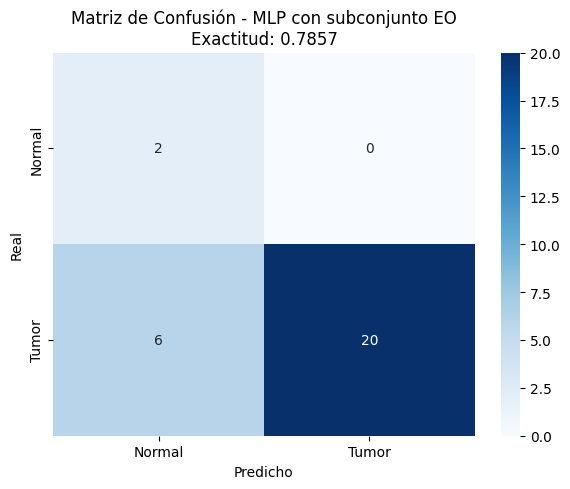


✅ Evaluación completada.


In [ ]:
# 6. VISUALIZACIÓN OPCIONAL: Matriz de confusión del mejor modelo
# ================================================================
best_name = best_subset
best_cm = results[best_name]['confusion_matrix']

plt.figure(figsize=(6,5))
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Tumor'],
            yticklabels=['Normal', 'Tumor'])
plt.title(f'Matriz de Confusión - MLP con subconjunto {best_name}\nExactitud: {results[best_name]["test_accuracy"]:.4f}')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

print("\n✅ Evaluación completada.")